<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/17_SVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM으로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존**과 **정보누수 방지**가 핵심입니다.


### 🐣 초보자를 위한 머신러닝 흐름 잡기

머신러닝으로 주가를 예측하는 과정은 **'과거의 시험공부'**와 비슷합니다.

1.  **데이터 수집**: 공부할 문제집(과거 주가 데이터)을 사는 단계입니다.
2.  **특징 생성(Feature Engineering)**: 문제집에서 시험에 나올만한 '핵심 요약'을 만드는 과정입니다. (예: 어제 성적이 좋았나? 최근 컨디션은 어떤가?)
3.  **데이터 분할**: 전체 문제집 중 일부는 공부용(Train)으로 쓰고, 나머지는 내 실력을 테스트할 모의고사(Test)용으로 남겨둡니다. 이때, 주식은 시간 순서가 중요하므로 '과거'로 공부하고 '미래'를 맞춰야 합니다.
4.  **모델 학습(SVM)**: 인공지능이 공부용 데이터를 보고 '상승'과 '하락'을 나누는 기준선을 그리는 연습을 합니다.
5.  **평가**: 모의고사(Test)를 풀어보고 얼마나 잘 맞췄는지 점수를 매깁니다.
6.  **예측**: 이제 실전입니다! 가장 최근 데이터를 넣어 '내일'의 방향을 예상해 봅니다.

In [9]:
# [초보자 설명] 주가 데이터를 기계가 이해할 수 있는 '신호'로 변환합니다.
df['ret1'] = df['Close'].pct_change() # 1일간의 수익률 (변화율)

# 과거 1일, 2일, 3일, 5일, 10일 전의 기록을 가져옵니다.
for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

# 이동평균선: 최근 주가의 평균 흐름을 나타냅니다.
df['ma5']  = df['Close'].rolling(5).mean()  # 단기 흐름
df['ma20'] = df['Close'].rolling(20).mean() # 중기 흐름

# ma_gap: 단기 흐름이 중기 흐름보다 위에 있는지(정배열), 아래에 있는지(역배열) 수치화
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0

# vol10: 변동성 (주가가 얼마나 요동치는지 나타내는 지표)
df['vol10'] = df['ret1'].rolling(10).std()

# 계산할 수 없는 초기 데이터(NaN)를 제거합니다.
df = df.dropna().reset_index(drop=True)
display(df.head())

Price,Date,Close,High,Low,Open,Volume,ret1,ret_lag1,ret_lag2,ret_lag3,ret_lag5,ret_lag10,ma5,ma20,ma_gap,vol10,ret_next,y_bin
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,,,,,,,,


## 0) 환경 준비
```bash
pip install yfinance
```


In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [11]:
# 데이터 수집 (최근 1년)
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 247


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성(Feature Engineering)

### 🔍 피처(Feature) 상세 설명

모델의 예측 성능을 높이기 위해 사용된 7가지 기술적 지표의 의미는 다음과 같습니다.

1. **`ret_lag1` ~ `ret_lag10` (Lagged Returns)**:
    * **설명**: 각각 1일 전, 2일 전, 3일 전, 5일 전, 10일 전의 주가 수익률입니다.
    * **의도**: 과거의 수익률 패턴이 내일의 방향성에 영향을 주는지 학습합니다 (예: 어제 올랐으면 오늘도 오를까?).

2. **`ma_gap` (MA Cross Over Distance)**:
    * **계산**: `(5일 이동평균 / 20일 이동평균) - 1.0`
    * **설명**: 단기 평단가(5일)와 중기 평단가(20일) 사이의 이격도입니다.
    * **의도**: 단기 추세가 장기 추세 대비 얼마나 과열되었는지 또는 골든/데드크로스 근처에 있는지를 나타냅니다.

3. **`vol10` (Rolling Volatility)**:
    * **계산**: 최근 10일간 수익률의 표준편차(Standard Deviation)
    * **설명**: 최근 시장의 변동성(위험도)을 측정합니다.
    * **의도**: 시장이 불안정한 상태(고변동성)인지 안정적인 상태(저변동성)인지에 따라 상승 확률이 달라지는지 확인합니다.

In [12]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 228


## 3) 타깃/분할(시간 순서 보존)


In [13]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (181, 7) Test: (46, 7)


## 4) 모델: Support Vector Machine (SVM)

### 🤖 SVM(Support Vector Machine)이란?
SVM은 데이터를 분류하기 위해 **최적의 결정 경계(Decision Boundary)**를 찾는 알고리즘입니다. 단순히 데이터를 나누는 것이 아니라, 두 클래스 사이의 거리를 최대화하는 **마진(Margin)**을 극대화하는 것이 핵심입니다.

#### 📐 수학적 원리
결정 초평면을 $w \cdot x + b = 0$이라고 할 때, SVM은 다음 조건하에서 $\frac{1}{2}\|w\|^2$을 최소화하는 문제를 풉니다:
$$y_i(w \cdot x_i + b) \ge 1$$

*   **Support Vectors**: 결정 경계에 가장 가까이 있는 데이터 포인트들입니다.
*   **Kernel Trick**: 데이터가 선형적으로 분리되지 않을 때, 고차원 공간으로 매핑하여 선형 분리가 가능하게 만듭니다. 본 코드에서는 **RBF(Radial Basis Function)** 커널을 사용합니다.

#### 🛠 주요 파라미터
1.  **C (Regularization)**: 오차를 얼마나 허용할지 결정합니다. C가 크면 오차를 적게 허용(Overfitting 위험), 작으면 마진을 넓게 설정(Underfitting 위험)합니다.
2.  **Gamma**: 하나의 데이터 샘플이 미치는 영향의 범위를 결정합니다.
3.  **StandardScaler**: SVM은 거리 기반 모델이므로, 모든 특징(Feature)의 스케일을 평균 0, 표준편차 1로 맞추는 과정이 필수적입니다.

In [14]:
from sklearn.svm import SVC
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])
model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])

## 5) 평가


[평가 결과] Accuracy: 0.4565
[평가 결과] ROC-AUC : 0.4763


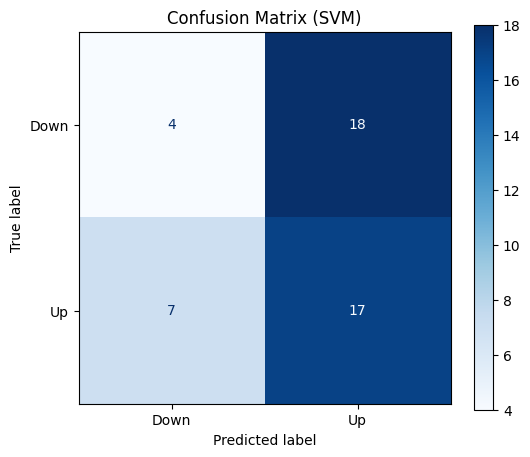


[해석 Guide]
- (0,0): 하락을 정확히 맞춘 경우 (True Negative)
- (1,1): 상승을 정확히 맞춘 경우 (True Positive)
- (0,1): 하락할 것 같았는데 상승한 경우 (False Positive)
- (1,0): 상승할 것 같았는데 하락한 경우 (False Negative)


In [15]:
import seaborn as sns

# 1. 성능 지표 계산
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"[평가 결과] Accuracy: {acc:.4f}")
if hasattr(model, 'predict_proba'):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print(f"[평가 결과] ROC-AUC : {auc:.4f}")

# 2. Confusion Matrix 시각화 및 해석
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up']).plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix (SVM)")
plt.show()

print("\n[해석 Guide]")
print("- (0,0): 하락을 정확히 맞춘 경우 (True Negative)")
print("- (1,1): 상승을 정확히 맞춘 경우 (True Positive)")
print("- (0,1): 하락할 것 같았는데 상승한 경우 (False Positive)")
print("- (1,0): 상승할 것 같았는데 하락한 경우 (False Negative)")

## ✅ 마지막 시각화: ROC Curve + 예측확률 분포(Up/Down)


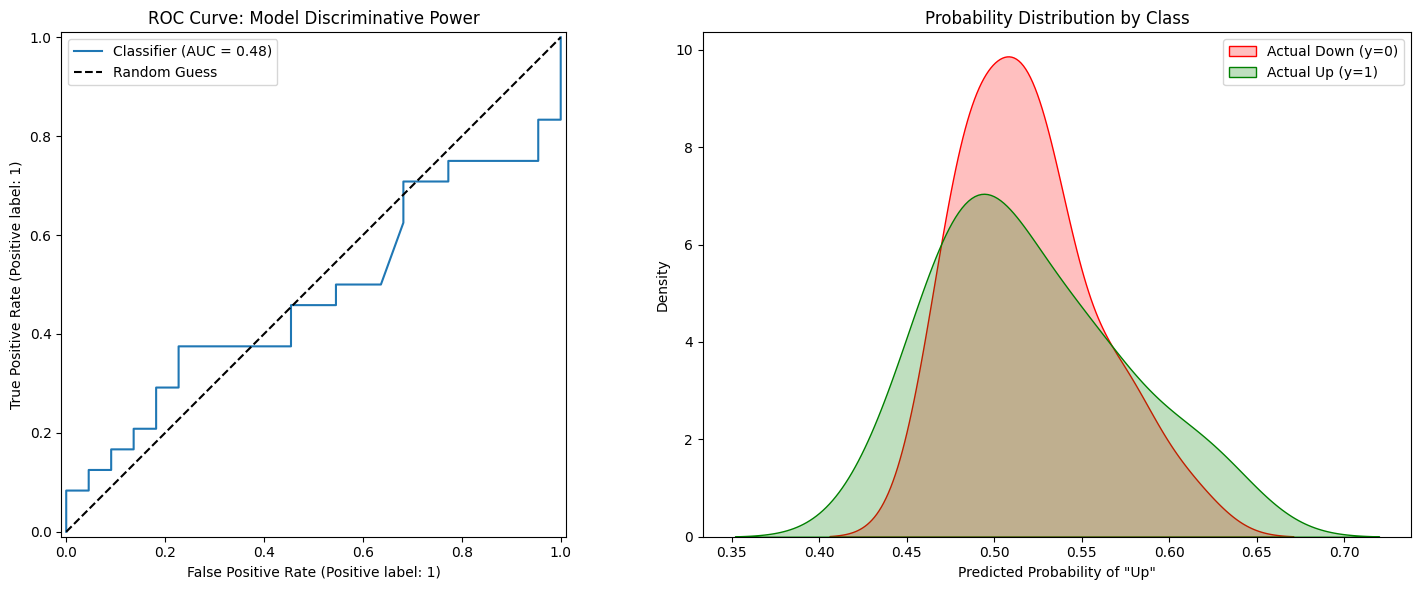


[시각화 해석]
1. ROC Curve: 곡선이 왼쪽 상단에 붙을수록 우수한 모델입니다. AUC 0.5는 무작위 추측과 같습니다.
2. 확률 분포: 빨간색(하락)은 왼쪽(0에 가깝게), 초록색(상승)은 오른쪽(1에 가깝게) 분포할수록 분류가 잘 된 것입니다.


In [16]:
y_proba = model.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. ROC Curve: 모델의 변별력 확인
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax1)
ax1.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax1.set_title('ROC Curve: Model Discriminative Power')
ax1.legend()

# 2. Probability Distribution: 예측 확신도 분석
sns.kdeplot(y_proba[y_test.values==0], ax=ax2, label='Actual Down (y=0)', fill=True, color='red')
sns.kdeplot(y_proba[y_test.values==1], ax=ax2, label='Actual Up (y=1)', fill=True, color='green')
ax2.set_title('Probability Distribution by Class')
ax2.set_xlabel('Predicted Probability of "Up"')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n[시각화 해석]")
print("1. ROC Curve: 곡선이 왼쪽 상단에 붙을수록 우수한 모델입니다. AUC 0.5는 무작위 추측과 같습니다.")
print("2. 확률 분포: 빨간색(하락)은 왼쪽(0에 가깝게), 초록색(상승)은 오른쪽(1에 가깝게) 분포할수록 분류가 잘 된 것입니다.")

## 8) 방향 예측(Up/Down) 출력 + 다음 거래일 예측
아래는 분류 모델의 예측을 ‘방향’ 관점에서 요약하고,
마지막 관측치의 특징으로 다음 거래일(표시상 +1일)의 Up/Down을 출력합니다.
※ 실제 거래일 캘린더(휴장일)는 반영하지 않습니다.


In [17]:
import numpy as np
import pandas as pd

# 예측된 값 (0: 하락, 1: 상승)의 개수 계산
prediction_counts = np.bincount(y_pred)

# 예측 결과 출력
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

# 마지막 관측치로 '다음 거래일' 방향 예측(예: 오늘 기준 내일 Up/Down)
last_day_features = X.iloc[-1].values.reshape(1, -1)

# 모델별 입력 형식 처리: Pipeline(예: SVM)은 그대로 넣으면 scaler까지 적용됨
next_day_prediction = model.predict(last_day_features)

prediction_label = "상승 (Up)" if int(next_day_prediction[0]) == 1 else "하락 (Down)"

# 예측 날짜(단순히 마지막 날짜 + 1일로 표시)
last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")


Predicted Down (하락): 11 건
Predicted Up (상승): 35 건
다음 거래일 예측 (날짜: 2026-03-24): 상승 (Up)


## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
